In [1]:
building = 1
time = 24
price = 'Realistic'

battery_capacity = 9.0

# Setup

In [2]:
import torch
import pandas as pd
import numpy as np
import math

import src.data.dataprep as prep
import src.data.featurisation as features

from src.models.lstm import LSTM
from src.models.lstmopt import LSTMOPT
from src.models.lstmopt import CVXLayer

from src.training.training import  Training as Training
from src.training.training_opt import Training as Training_opt

import src.optimization.pv_battery as pvb

import src.tensors.tensorisation as tensor

import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error as mse

def torch_py(torch_tensor):
    return torch_tensor.cpu().detach().numpy().flatten()

def rescale(values, scaler):
    rescaled_values = values * (scaler[1] - scaler[0]) + scaler[0]   
    return rescaled_values

def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

In [3]:
# Import the base data and resample it from 5 minutes to hourly
nl_data = prep.dutch_data('../data/Dutchdata_clean/building_' + str(building) + '.parquet', 'h', price=price)

In [4]:
featurisation = features.Featurisation(nl_data)
nl_data = featurisation.cyclic_features(yearly=False)[0]
nl_data.head()

,load,solar_energy,net_load,offtake,injection,cost,hour_sin,hour_cos
2018-07-01 00:00:00,0.556,0.0,0.556,0.18878,0.030,0.104962,0.000000,1.000000
2018-07-01 01:00:00,0.333,0.0,0.333,0.18178,0.024,0.060533,0.258819,0.965926
2018-07-01 02:00:00,0.347,0.0,0.347,0.17278,0.018,0.059955,0.500000,0.866025
2018-07-01 03:00:00,0.340,0.0,0.340,0.16278,0.010,0.055345,0.707107,0.707107
2018-07-01 04:00:00,0.289,0.0,0.289,0.16478,0.012,0.047621,0.866025,0.500000


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Parameters

In [6]:
# Base parameters
max_charge = battery_capacity/2.7
max_discharge = max_charge
layers = 3
neurons = 200
features = 3
train_test_split = 0.6

past_features = ['solar_energy']
future_features = ['hour_sin','hour_cos']
opt_future_features = ['hour_sin','hour_cos','load','offtake','injection']
domain_min = [None, None, None, 0, 0, 0, None]
domain_max = [None, None, None, 1, 1, 1, None]

In [7]:
pvb_system = pvb.PV_battery(nl_data, building, battery_capacity, max_charge, max_discharge, self_consumption=False)

In [34]:
dictionary_list_perfect = pvb_system.execute_optimization(time,13,'Perfect',neurons,layers,past_features,opt_future_features,domain_min,domain_max,train_test_split=train_test_split)
dictionary_list_naive = pvb_system.execute_optimization(time,13,'Naive',neurons,layers,past_features,opt_future_features,domain_min,domain_max,train_test_split=train_test_split)
dictionary_list_lstm = pvb_system.execute_optimization(time,13,'LSTM',neurons,layers,past_features,opt_future_features,domain_min,domain_max,train_test_split=train_test_split)
dictionary_list_cvx = pvb_system.execute_optimization(time,13,'CVX',neurons,layers,past_features,opt_future_features,domain_min,domain_max,train_test_split=train_test_split)
dictionary_list_lstm_cvx = pvb_system.execute_optimization(time,13,'LSTM_CVX',neurons,layers,past_features,opt_future_features,domain_min,domain_max,train_test_split=train_test_split)

Setting up optimization for hour 24
Forecasting PV
Obtaining initial energy parameters for hour 1


C:\Users\jdepoort\Anaconda3\lib\site-packages\cvxpy\reductions\solvers\solving_chain.py:336: FutureWarning: 
    Your problem is being solved with the ECOS solver by default. Starting in 
    CVXPY 1.5.0, Clarabel will be used as the default solver instead. To continue 
    using ECOS, specify the ECOS solver explicitly using the ``solver=cp.ECOS`` 
    argument to the ``problem.solve`` method.
    
  warnings.warn(ECOS_DEPRECATION_MSG, FutureWarning)


Setting up optimization for hour 23
Forecasting PV
Obtaining initial energy parameters for hour 2
Setting up optimization for hour 22
Forecasting PV
Obtaining initial energy parameters for hour 3
Setting up optimization for hour 21
Forecasting PV
Obtaining initial energy parameters for hour 4
Setting up optimization for hour 20
Forecasting PV
Obtaining initial energy parameters for hour 5
Setting up optimization for hour 19
Forecasting PV
Obtaining initial energy parameters for hour 6
Setting up optimization for hour 18
Forecasting PV
Obtaining initial energy parameters for hour 7
Setting up optimization for hour 17
Forecasting PV
Obtaining initial energy parameters for hour 8
Setting up optimization for hour 16
Forecasting PV
Obtaining initial energy parameters for hour 9
Setting up optimization for hour 15
Forecasting PV
Obtaining initial energy parameters for hour 10
Setting up optimization for hour 14
Forecasting PV
Obtaining initial energy parameters for hour 11
Setting up optimiz

In [61]:
hours = range(0,11)

In [62]:
tot_cost_perfect = []
tot_cost_lstm = []
tot_cost_cvx_lstm = []

for hour in hours:
    perfect_cost = (dictionary_list_perfect[hour]['offtake'][:,0] * dictionary_list_perfect[hour]['imp'][:,0]) - (dictionary_list_perfect[hour]['injection'][:,0] * dictionary_list_perfect[hour]['exp'][:,0])
    naive_cost = (dictionary_list_naive[hour]['offtake'][:,0] * dictionary_list_naive[hour]['imp'][:,0]) - (dictionary_list_naive[hour]['injection'][:,0] * dictionary_list_naive[hour]['exp'][:,0])
    lstm_cost = (dictionary_list_lstm[hour]['offtake'][:,0] * dictionary_list_lstm[hour]['imp'][:,0]) - (dictionary_list_lstm[hour]['injection'][:,0] * dictionary_list_lstm[hour]['exp'][:,0])
    cvx_cost = (dictionary_list_cvx[hour]['offtake'][:,0] * dictionary_list_cvx[hour]['imp'][:,0]) - (dictionary_list_cvx[hour]['injection'][:,0] * dictionary_list_cvx[hour]['exp'][:,0])
    lstm_cvx_cost = (dictionary_list_lstm_cvx[hour]['offtake'][:,0] * dictionary_list_lstm_cvx[hour]['imp'][:,0]) - (dictionary_list_lstm_cvx[hour]['injection'][:,0] * dictionary_list_lstm_cvx[hour]['exp'][:,0])
    
    tot_cost_perfect.append(sum(perfect_cost))
    tot_cost_lstm.append(sum(lstm_cost))
    tot_cost_cvx_lstm.append(sum(lstm_cvx_cost))

In [66]:
sum(tot_cost_perfect), sum(tot_cost_lstm), sum(tot_cost_cvx_lstm)

(67.88001678340169, 72.74459071846337, 59.270838000485284)

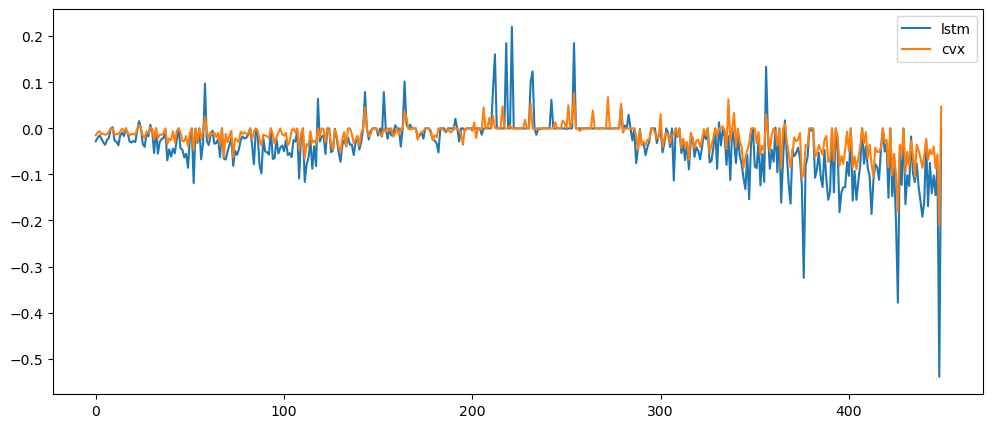

In [52]:
plt.figure(figsize=(12,5))
plt.plot(lstm_cost, label="lstm")
plt.plot(lstm_cvx_cost, label="cvx")

plt.legend()
plt.show()